In [54]:
from spin_lattices import KagomeLattice, SpinLattice, SquareLattice, TriangleLattice
from heisenberg_hamiltonians import HeisenbergJ1J2, SpinSystem
from fast_boolean_analysis import (
    keep_largest_n,
    keep_everything,
    ScorerType,
    get_scorer,
    FourierSeries,
    fourier_expand,
)

from lattice_boolean_analysis import (
    AmplitudeMedianBinSignalKind,
    SignSignalKind,
    AmplitudeSignalKind,
    SignalKind,
    LBFFromSpinSystem,
)

import json

from loguru import logger

from pathlib import Path
import numpy as np
import pandas as pd
import lattice_symmetries as ls
import matplotlib.pyplot as plt
from itertools import product
import numpy.typing as npt
from tqdm import tqdm
import seaborn as sns
import parse
import sys
from typing import NamedTuple
from utils import read_jsonl_to_df

from parity import popcount
from dataclasses import dataclass, astuple

ground_state_cache_dir = Path("groundstates")

outdir = Path("experiments/boolean-analysis-complexity")
outdir.mkdir(exist_ok=True, parents=True)

outfile = outdir / "complexity.jsonl"


def get_score_column(df: pd.DataFrame, scorer: str) -> list:
    return [
        row["series"].truncate(keep_largest_n(row["terms"])).prediction_score(scorer=scorer)
        for _, row in (df.iterrows())
    ]

logger.remove()
logger.add(Path("boolean-analysis-complexity.ipynb.log", level="DEBUG", colorize=True))

4

In [2]:
%matplotlib inline

In [3]:
name_to_lat_and_sym = {
    lat_and_sym[0].get_cache_id(): lat_and_sym
    for lat_and_sym in [
        (KagomeLattice(width=3, height=3), False),
        (KagomeLattice(width=2, height=2), False),
    ]
}

name_to_signal_kind = {
    signal.name: signal for signal in [AmplitudeMedianBinSignalKind(), SignSignalKind()]
}


In [5]:
df = read_jsonl_to_df(outfile).dropna()

In [44]:
df_nodup = df.drop(['largest_terms', 'largest_coeffs'], axis=1).drop_duplicates()

In [56]:
df_nodup[
    df_nodup.duplicated(
        subset=["lattice_name", "J2", "signal_kind","target_scorer", "target_score"],
        keep=False,
    )
]


,lattice_name,J2,signal_kind,success,terms,target_score,target_scorer,sign_overlap,accuracy,f1,total_hamming_weight,number_spins


In [64]:
def mk_filename(row):
    return "-".join([f"{col}={row[col]}" for col in ["lattice_name", "J2", "signal_kind"]]) + ".json"

In [65]:
list(
    df[~df.drop(['largest_terms', 'largest_coeffs'], axis=1).duplicated()].to_dict(orient='index').items()
)[0]

(44,
 {'lattice_name': 'KagomeLattice2x2',
  'J2': 0.0,
  'signal_kind': 'sign',
  'success': True,
  'terms': 1,
  'target_score': 0.8,
  'target_scorer': 'f1',
  'sign_overlap': 1.0,
  'accuracy': 1.0,
  'f1': 1.0,
  'total_hamming_weight': 2.0,
  'number_spins': 12.0,
  'largest_terms': [165],
  'largest_coeffs': [-14.4375]})

In [63]:
for i, row in df[~df.drop(['largest_terms', 'largest_coeffs'], axis=1).duplicated()].to_dict(orient='index').items():
    filename = mk_filename(row)
    (Path(outdir) / filename).write_text(json.dumps(row, indent=4))

In [15]:
series_df = df.assign(
    mean_hw=lambda df: df["total_hamming_weight"] / df["terms"],
).set_index(["lattice_name", "J2", "signal_kind"]).sort_index()


In [8]:
series_df.query('success == False')

,,,success,terms,target_score,target_scorer,sign_overlap,accuracy,f1,total_hamming_weight,number_spins,largest_terms,largest_coeffs,mean_hw
lattice_name,J2,signal_kind,,,,,,,,,,,,


In [9]:
np.log2(series_df.query('lattice_name.str.startswith("Kagome")').groupby('number_spins')['terms'].max())

number_spins
12.0     5.954196
18.0    10.336507
24.0    14.882500
27.0    18.187342
Name: terms, dtype: float64

In [10]:
%matplotlib inline

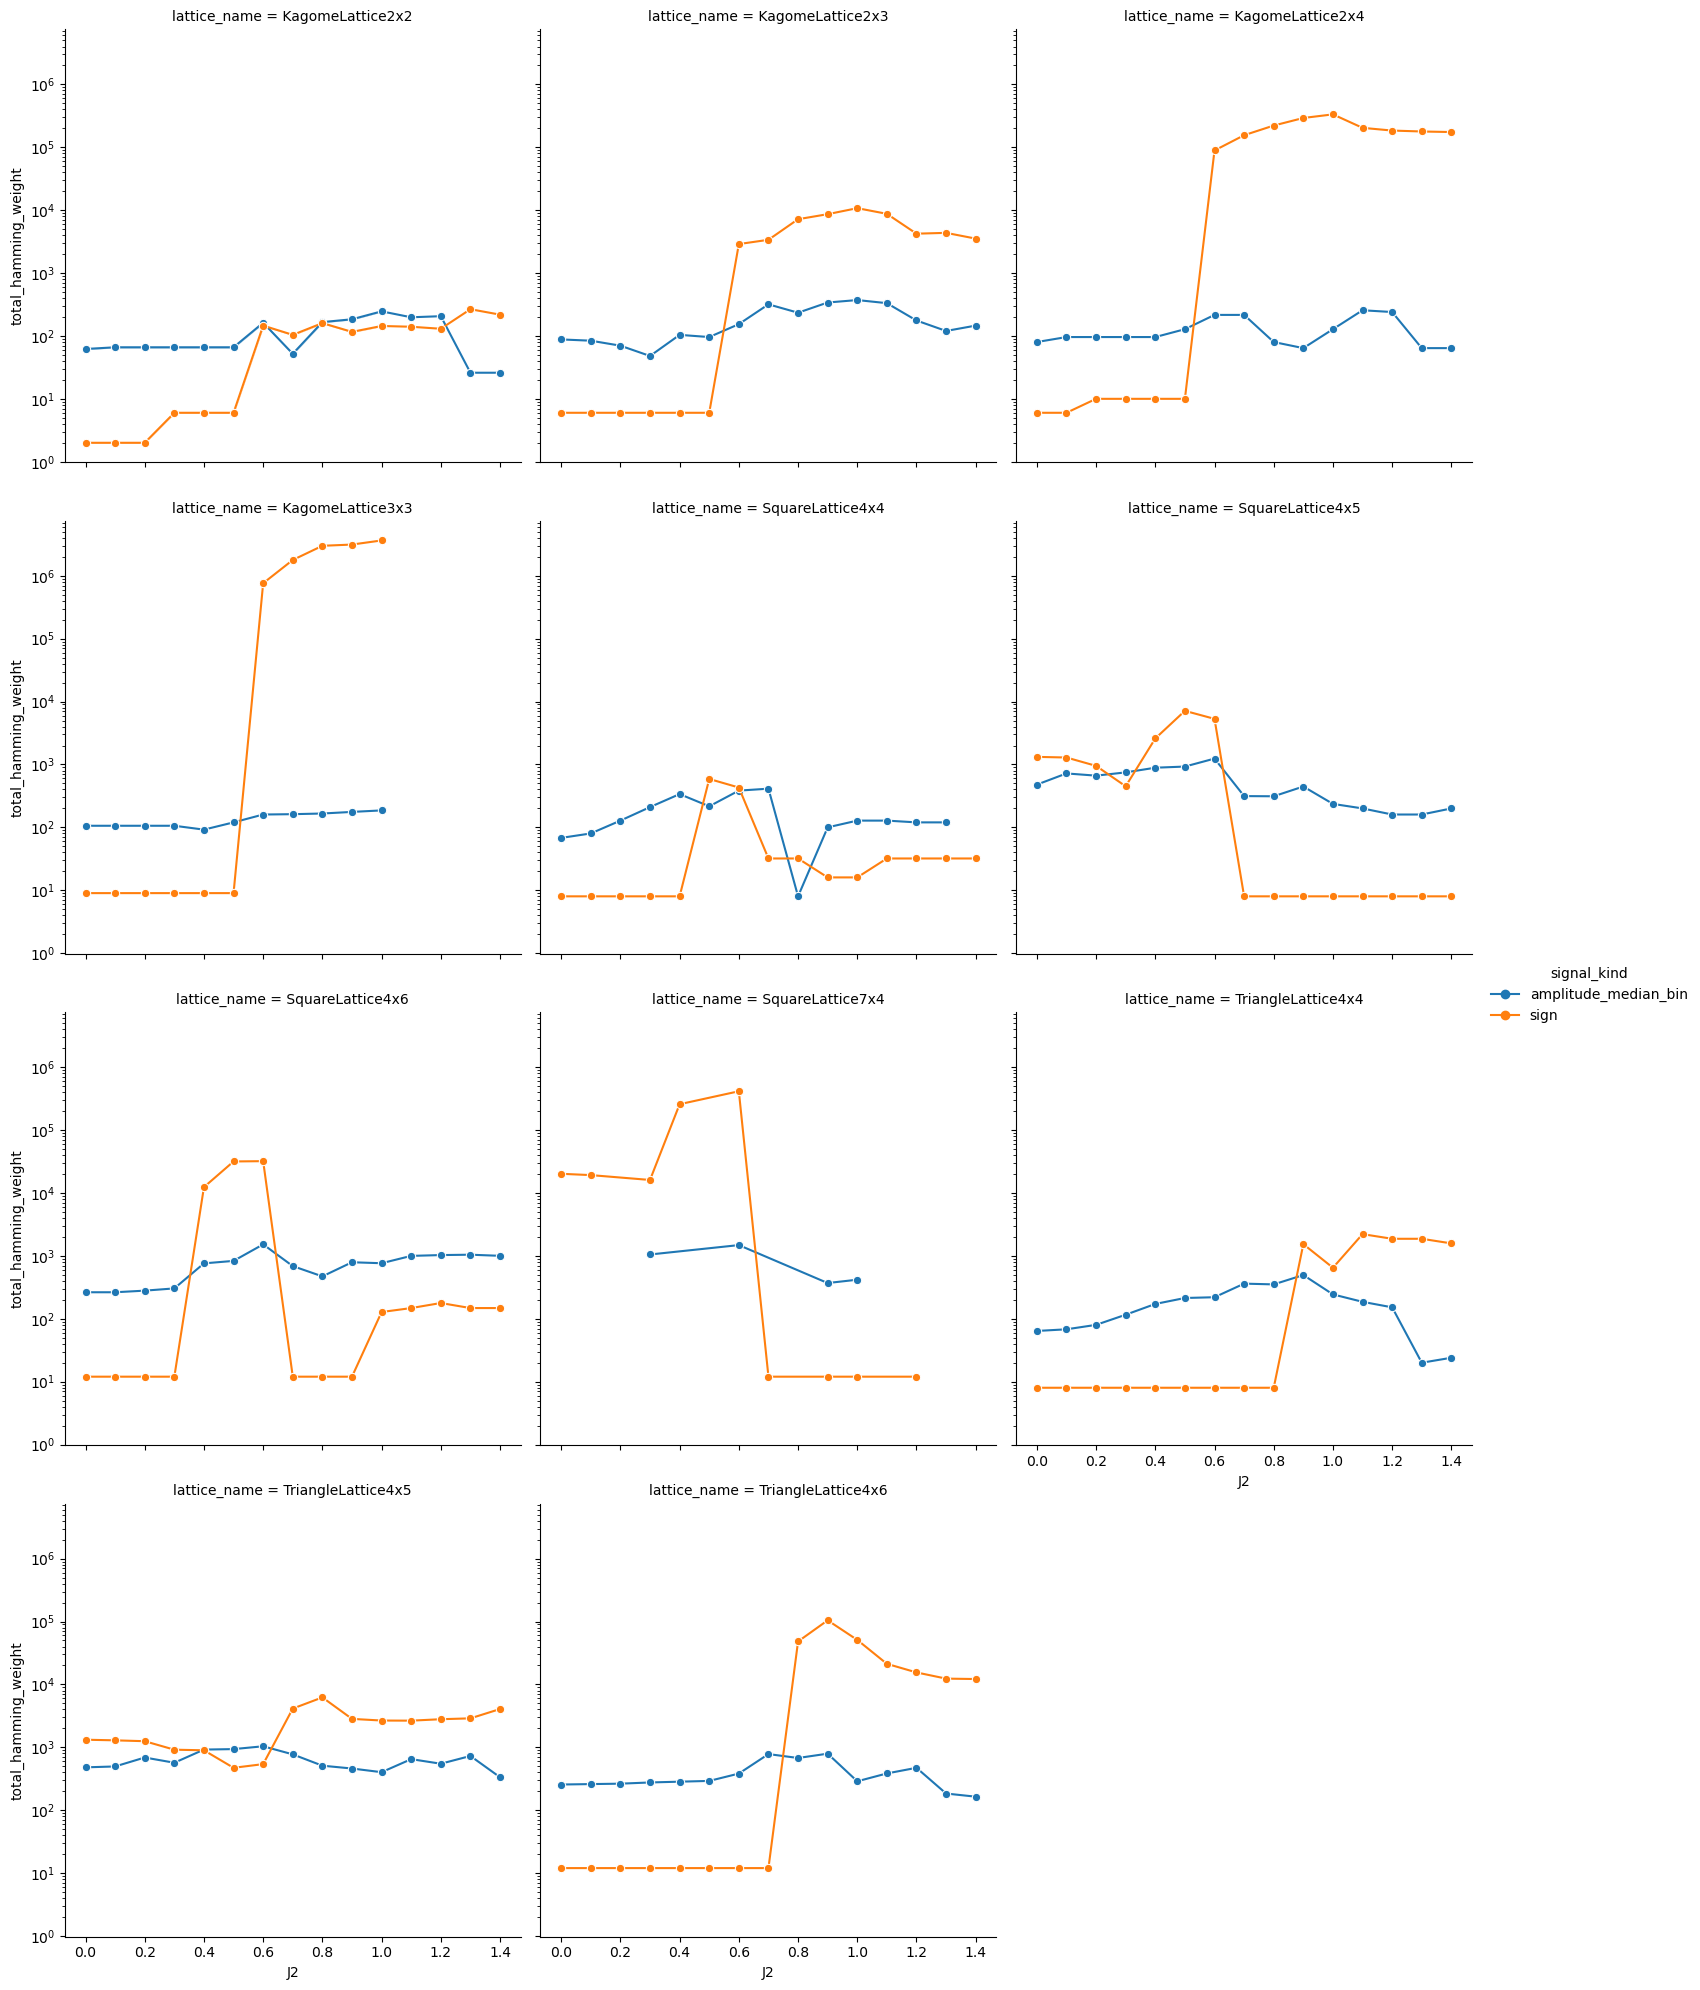

In [16]:
sns.relplot(
    series_df.reset_index(),
    x="J2",
    y="total_hamming_weight",
    hue="signal_kind",
    col="lattice_name",
    col_wrap=3,
    kind="line",
    # markers=True,
    style="signal_kind",
    dashes=False,
    markers=["o", "o"],
    # make y axis independent
    # facet_kws=dict(sharey=False),
).set(yscale="log")


[None]

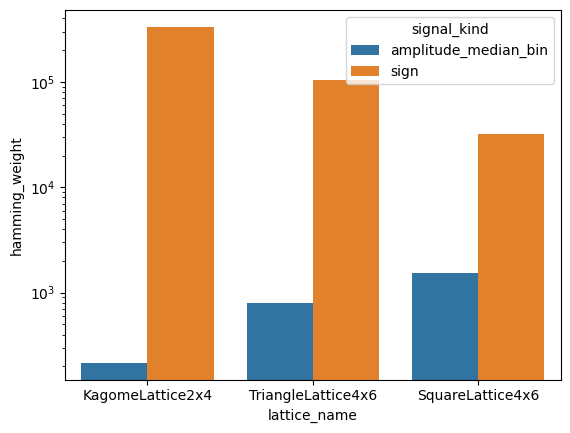

In [79]:
sns.barplot(series_df.query("number_spins == 24").reset_index().groupby(["lattice_name", "signal_kind"])[
    ["terms", "hamming_weight"]
].max().sort_values('hamming_weight').reset_index(), x='lattice_name', y='hamming_weight', hue='signal_kind').set(yscale='log')


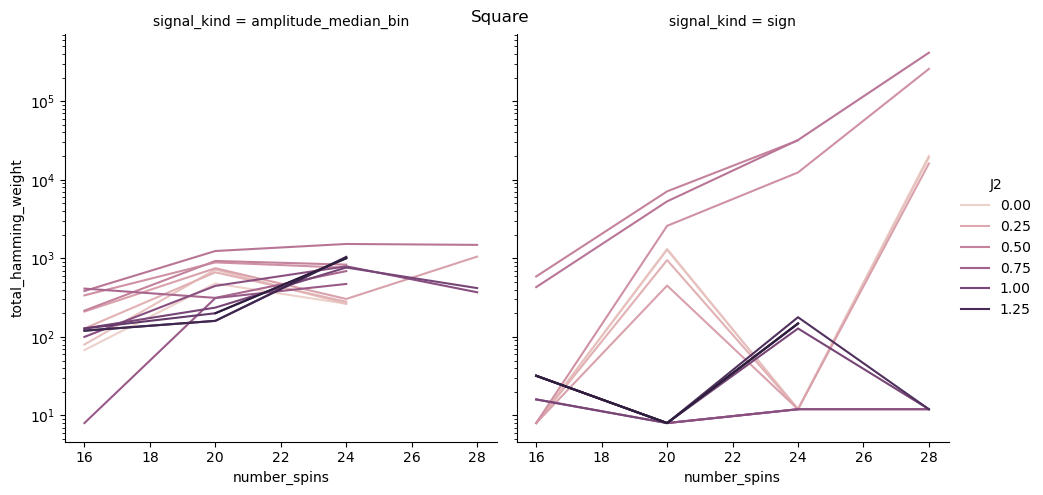

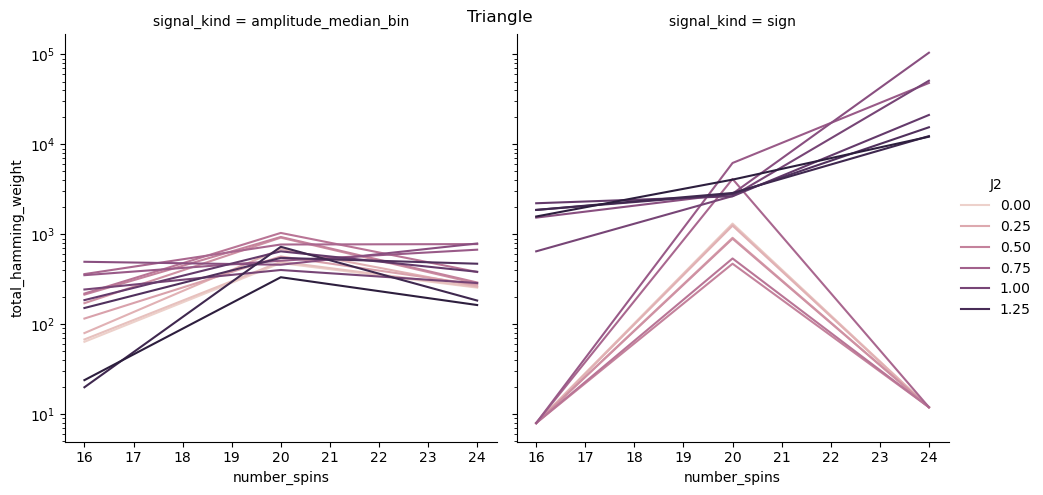

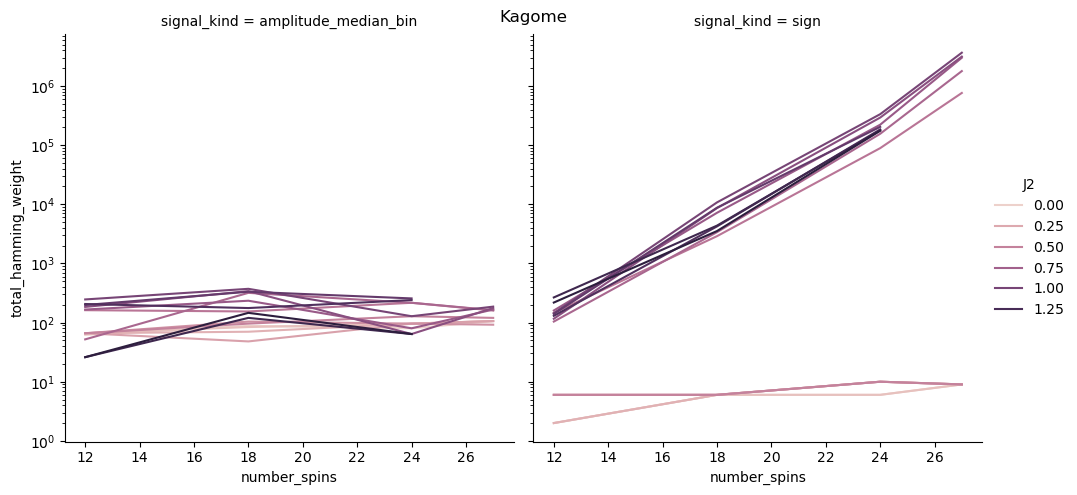

In [18]:
for lat in ['Square', 'Triangle', 'Kagome']:
    
    plot = sns.relplot(
        series_df.reset_index().query('lattice_name.str.startswith(@lat)'),
        x="number_spins",
        y="total_hamming_weight",
        col="signal_kind",
        hue="J2",
        kind="line",
        markers=True,
    ).set(yscale="log")
    plot.fig.suptitle(lat)


In [64]:
def plot_subsets(subsets, titles, lat: SpinLattice):
    fig, axes = plt.subplots(1, len(subsets), figsize=(len(subsets) * 3, 3), squeeze=False)
    for ax, subset, title in zip(axes[0], subsets, titles):
        lat.plot(spins=subset, ax=ax)
        ax.axis("off")
        ax.set_title(title)
    return fig


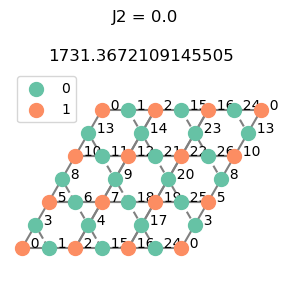

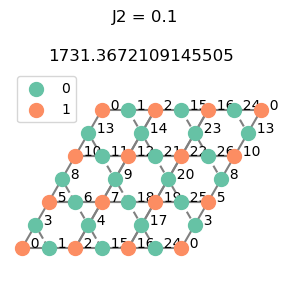

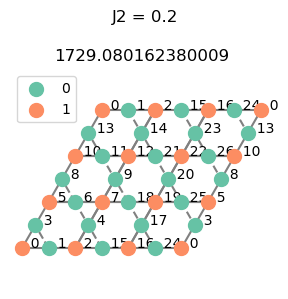

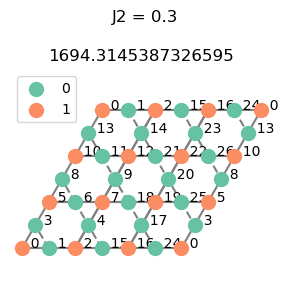

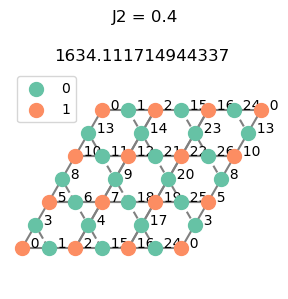

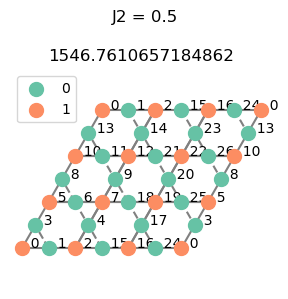

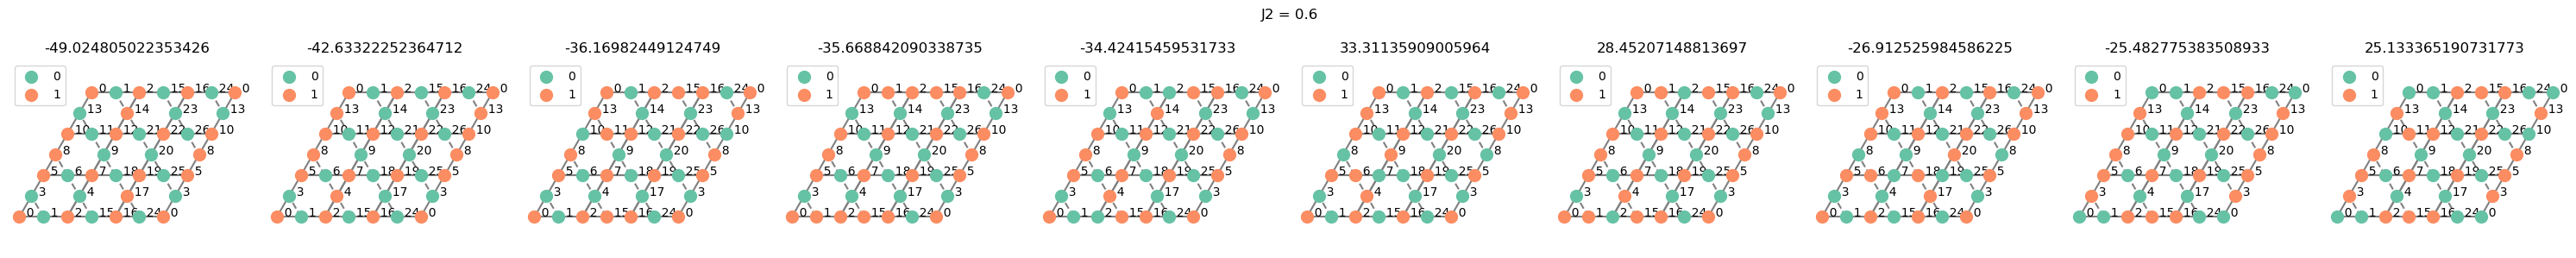

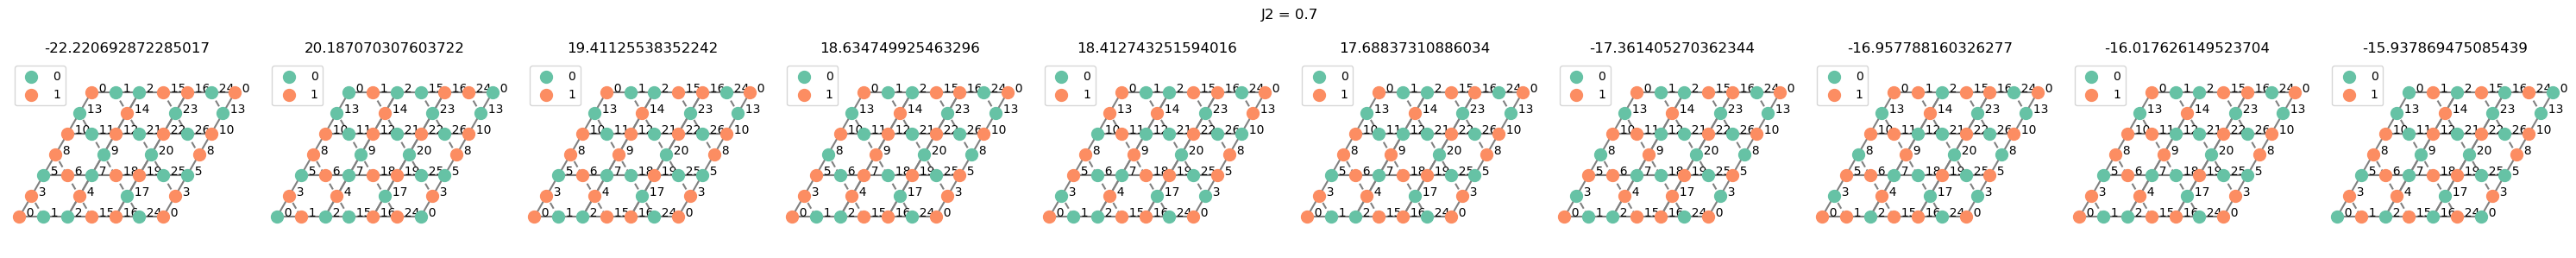

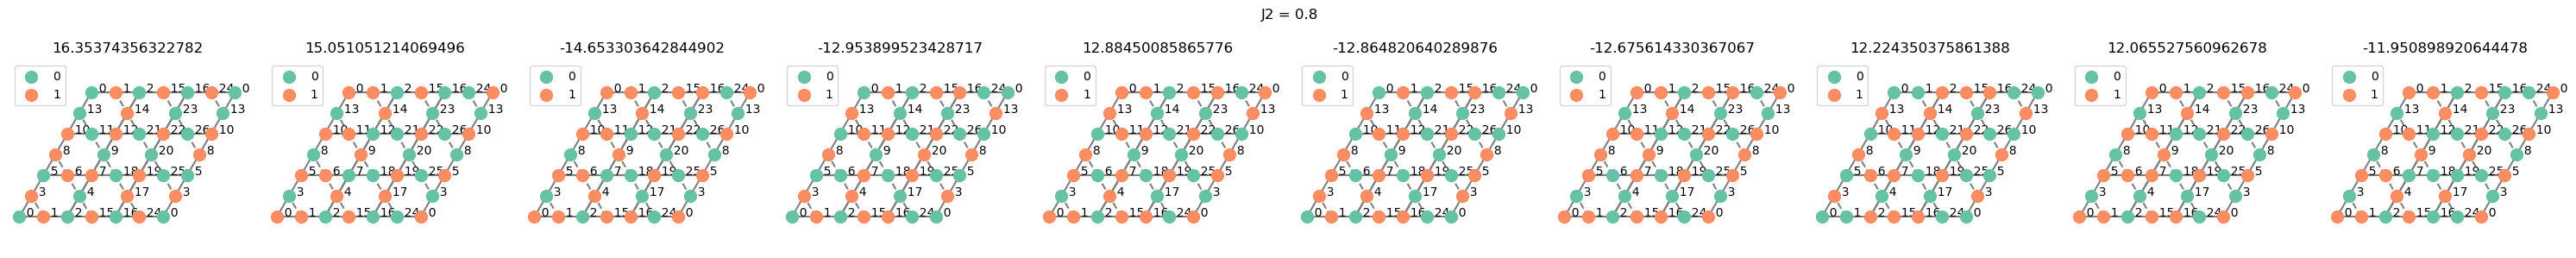

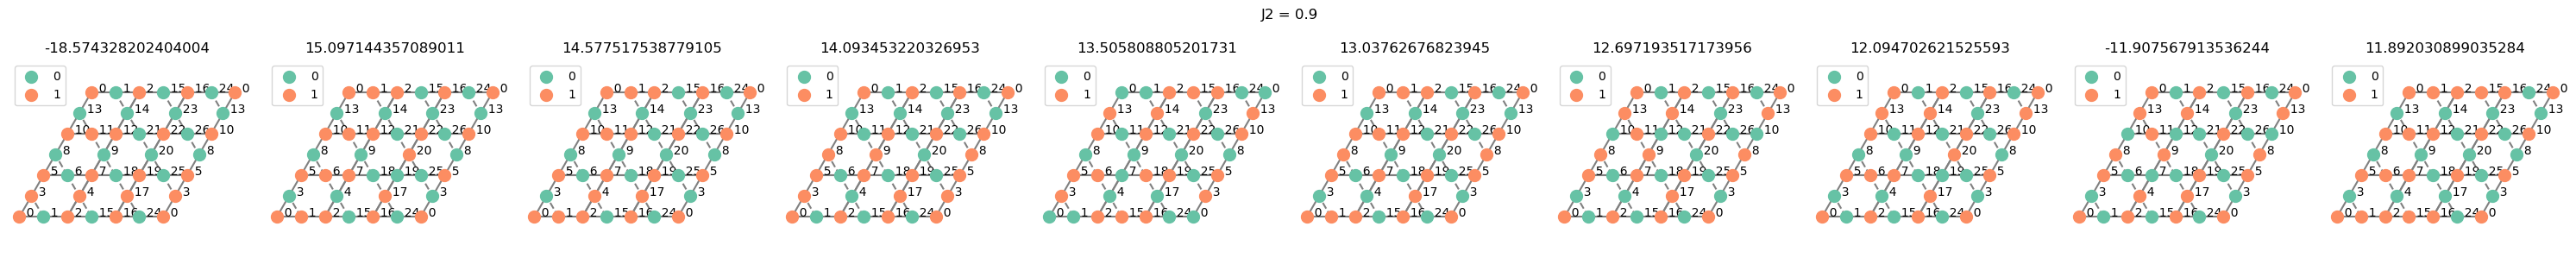

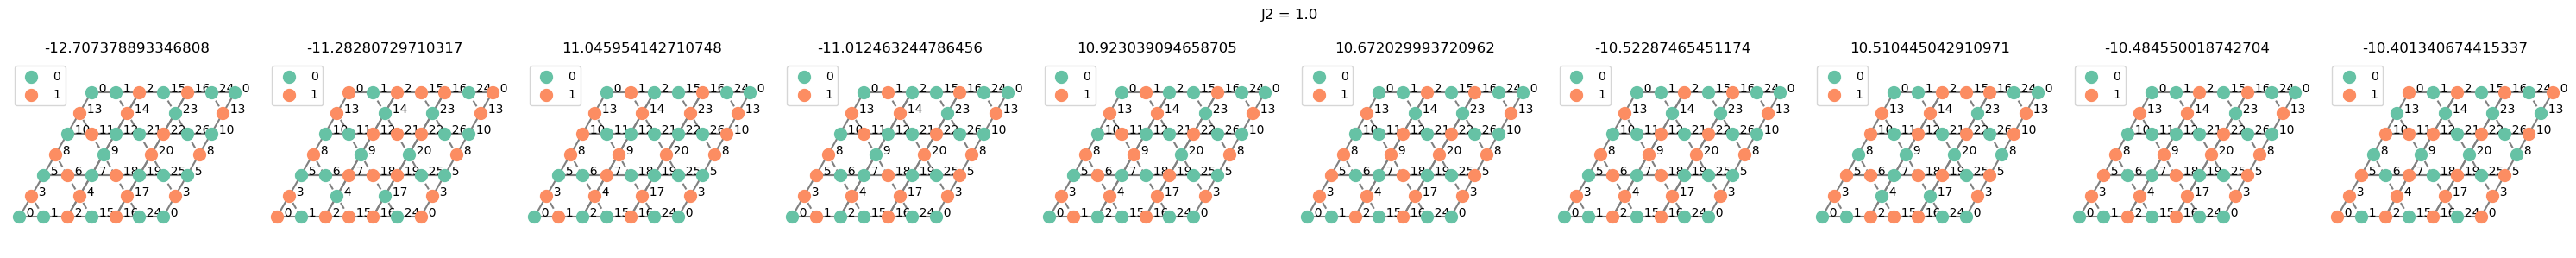

In [73]:
lattice_name = 'KagomeLattice3x3'
signal = "sign"

for J2, row in (
    series_df.sort_index(level="J2")
    .xs((lattice_name, signal), level=("lattice_name", "signal_kind"))
    .iterrows()
):
    subsets = row["largest_terms"]
    coeffs = row["largest_coeffs"]

    fig = plot_subsets(subsets, coeffs, name_to_lat_and_sym[lattice_name][0])
    fig.suptitle(f"J2 = {J2}")
    fig.tight_layout()
    fig.show()



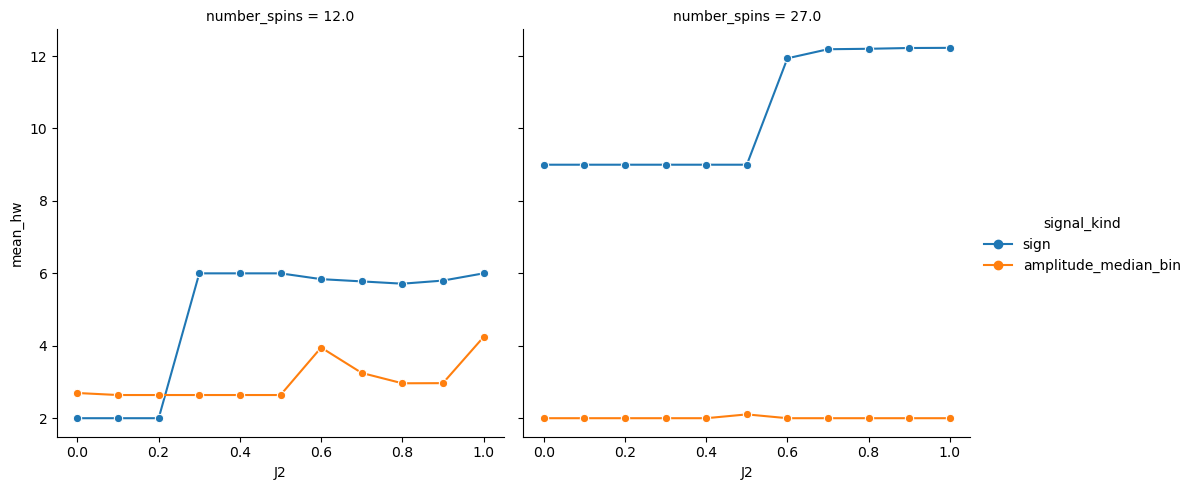

In [45]:
sns.relplot(
    series_df,
    x="J2",
    y="mean_hw",
    hue="signal_kind",
    col="number_spins",
    kind="line",
    dashes=False,
    style="signal_kind",
    markers=["o", "o"],
)


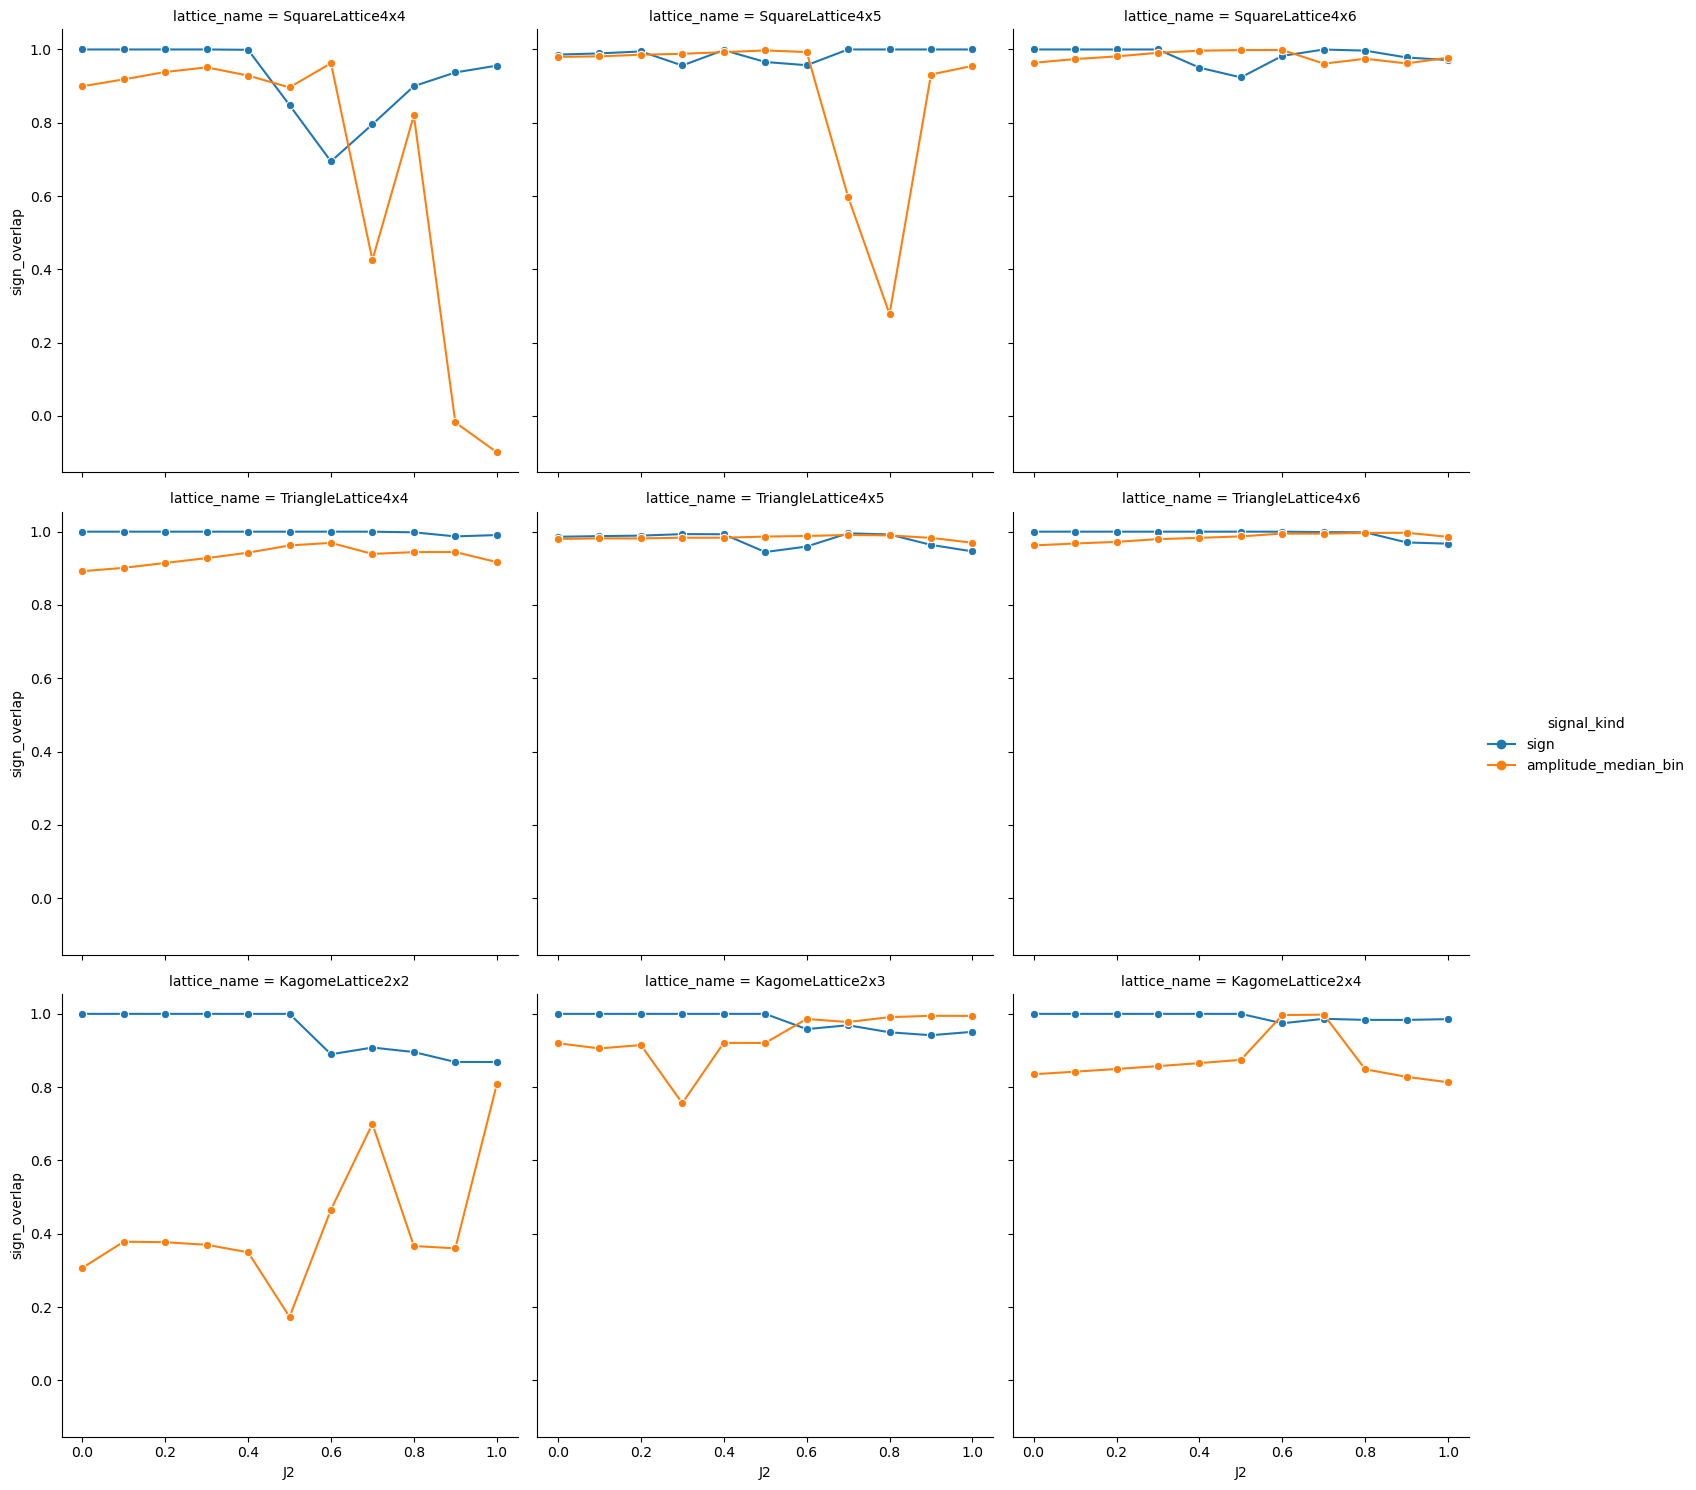

In [96]:
sns.relplot(
    series_df.reset_index(),
    x="J2",
    y="sign_overlap",
    hue="signal_kind",
    col="lattice_name",
    col_wrap=3,
    kind="line",
    dashes=False,
    style="signal_kind",
    markers=["o", "o"],
)


In [97]:
complexity_ratio_df = (
    series_df.unstack(level="signal_kind")["hamming_weight"]
    .assign(ratio=lambda df: df["sign"] / df["amplitude_median_bin"])
    .reset_index()
)


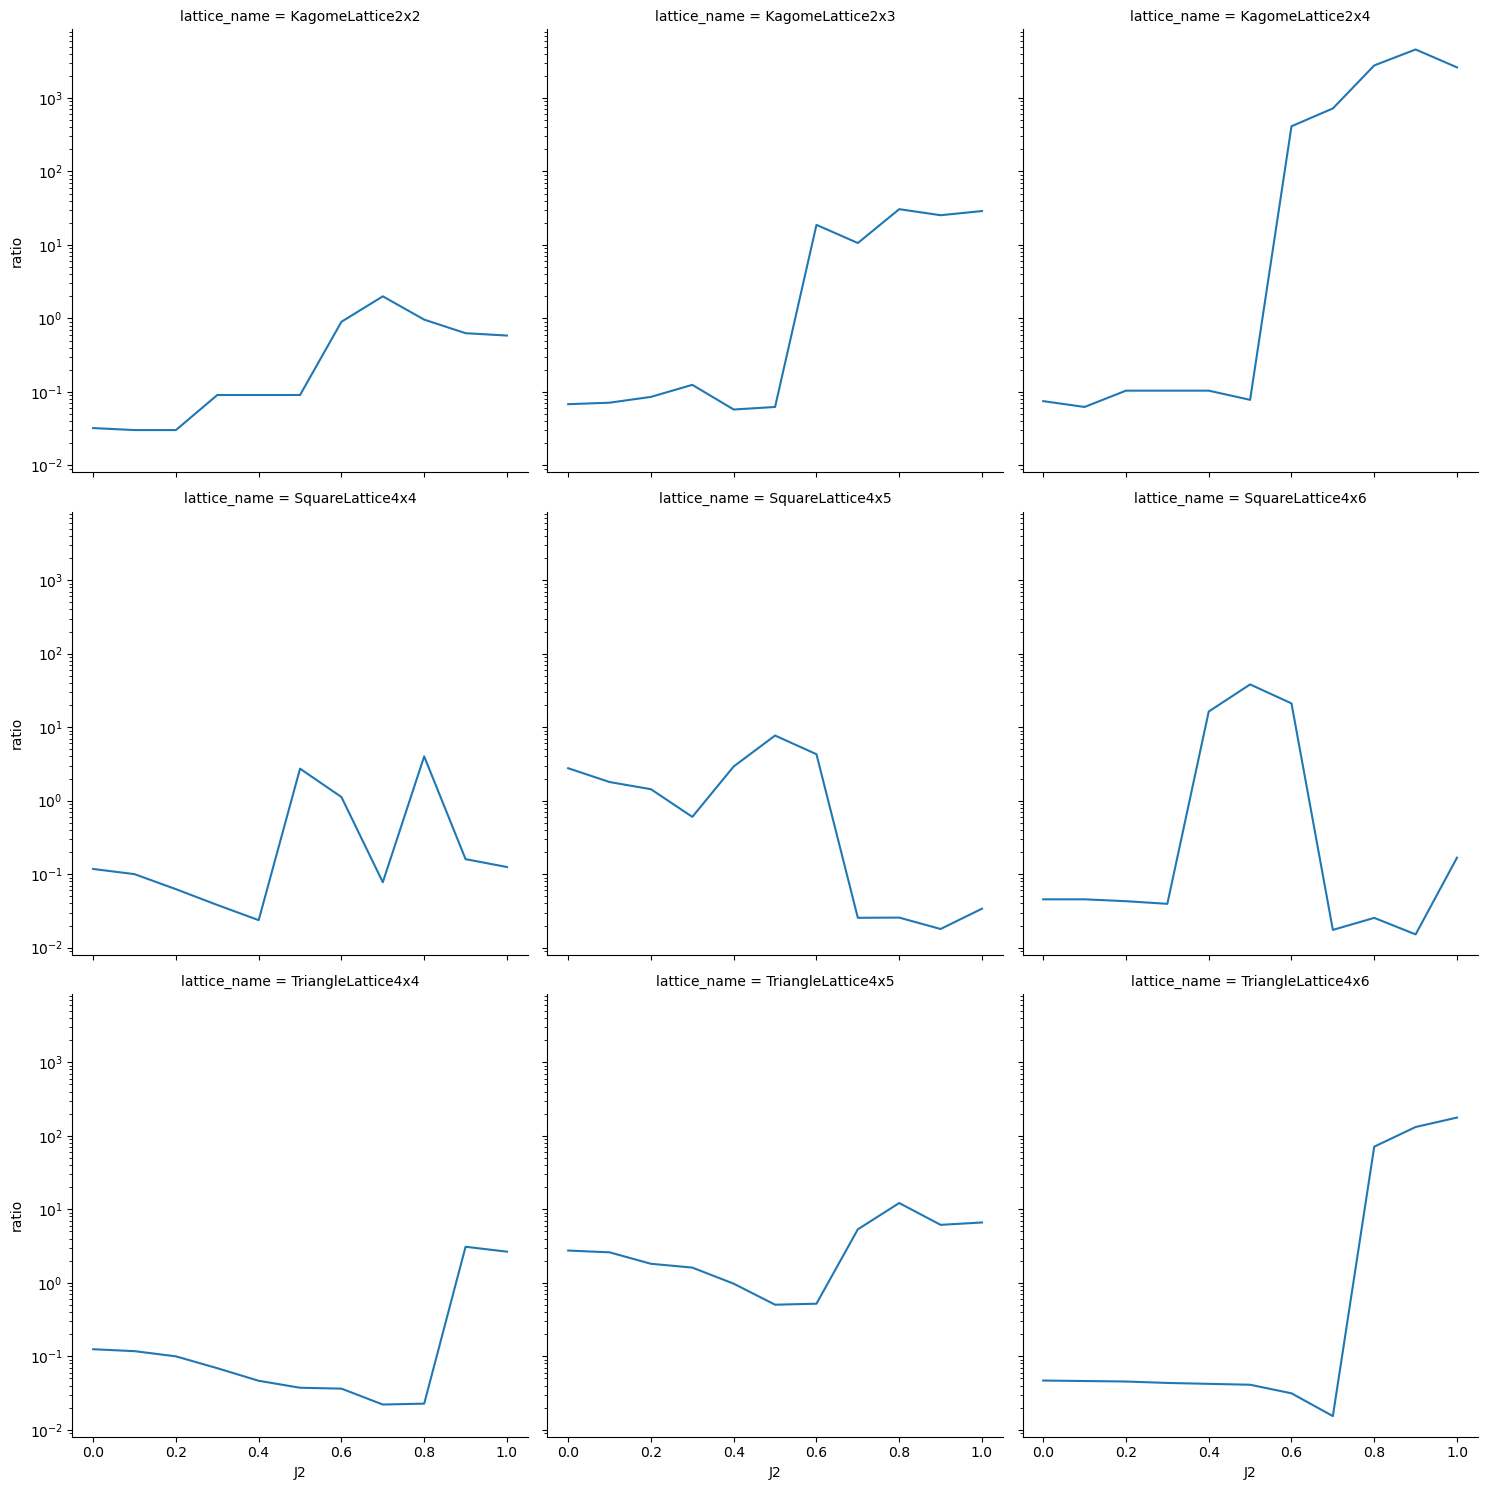

In [99]:
sns.relplot(complexity_ratio_df, x="J2", y="ratio", col="lattice_name", col_wrap=3,kind="line").set(yscale="log")


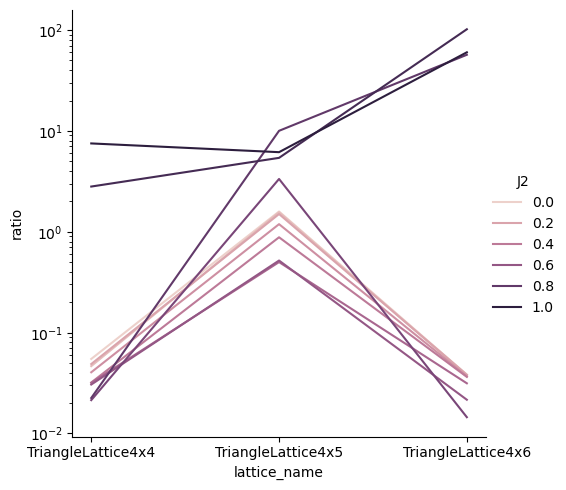

In [28]:
sns.relplot(
    complexity_ratio_df,
    x="lattice_name",
    y="ratio",
    hue="J2",
    kind="line",
).set(yscale="log")
